In [23]:
### 1) Desactivar GPUs y cargar librerías
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay,multilabel_confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers, backend as K
from tensorflow.keras.metrics import BinaryAccuracy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Si dispones de una función augment_sequence, la importas aquí
# try:
#     from library.functions import augment_sequence
# except ImportError:
#     print("No se encontró augment_sequence, comentar la sección de augmentación si es necesario.")


In [24]:
### 2) Carga de datos
keypoints_data = pd.read_csv(
    'D:/la-u/ciclo 2025-1/Seminario/Proyecto/DATASETS_CSV/keypoints_padded_with_mask_unilado.csv'
)
labels_data = pd.read_csv(
    'D:/la-u/ciclo 2025-1/Seminario/Proyecto/DATASETS_CSV/dataset_errores.csv',
    sep=','
)

keypoints_data['video_filename'] = keypoints_data['video_filename'].str.strip()
labels_data['nombre_video']    = labels_data['nombre_video'].str.strip()


In [25]:
### 3) Filtrado de landmarks y preparación de etiquetas
landmarks_to_keep = [23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
print(f"Número de landmarks seleccionados: {len(landmarks_to_keep)}")

# Filtramos solo esos landmarks
keypoints_data = keypoints_data[keypoints_data['landmark_index'].isin(landmarks_to_keep)].reset_index(drop=True)

# Convertir 'lado' a numérico
# labels_data['lado'] = labels_data['lado'].map({'I': 0, 'D': 1})

error_cols = [
    'giro_incompleto', 'pierna_patea_flexionada', 'pierna_base_flexionada',
    'pie_sin_borde_externo', 'preparacion_incompleta', 'recogida_incompleta'
]
all_cols = error_cols
labels_dict = labels_data.set_index('nombre_video')[all_cols].to_dict(orient='index')


Número de landmarks seleccionados: 10


In [26]:
video_frames = {}

def angle(a, b, c):
    ba = a - b
    bc = c - b
    cos = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))

landmarks = landmarks_to_keep

for (video, frame), group in keypoints_data.groupby(['video_filename', 'frame']):
    group_sorted = group.sort_values(by='landmark_index')

    # --- (1) Coordenadas originales
    pts = group_sorted[['x', 'y', 'z']].values
    vis = group_sorted['visibility'].values[:, None]

    # --- (2) Ponderar coordenadas por visibilidad
    pts_weighted = pts * vis  # (N_landmarks, 3)

    # --- (3) Concatenar coordenadas ponderadas + visibilidad como features
    # Esto da más robustez al modelo (tiene las coords confiables y el "score" de visibilidad)
    frame_vec = np.hstack([pts_weighted, vis]).flatten()

    # Calcular ángulos biomecánicos
    idx = {lm:i for i, lm in enumerate(landmarks)}
    L_HIP, R_HIP = pts[idx[23]], pts[idx[24]]
    L_KNEE, R_KNEE = pts[idx[25]], pts[idx[26]]
    L_ANK,  R_ANK  = pts[idx[27]], pts[idx[28]]
    L_HEEL, R_HEEL = pts[idx[29]], pts[idx[30]]
    L_FI,   R_FI   = pts[idx[31]], pts[idx[32]]

    ang_knee_L  = angle(L_HIP,  L_KNEE, L_ANK)
    ang_knee_R  = angle(R_HIP,  R_KNEE, R_ANK)
    ang_ankle_L = angle(L_KNEE, L_ANK,  L_HEEL)
    ang_ankle_R = angle(R_KNEE, R_ANK,  R_HEEL)
    ang_ankle_L2 = angle(L_KNEE, L_ANK,  L_FI)
    ang_ankle_R2 = angle(R_KNEE, R_ANK,  R_FI)

    # Vectores dirección del pie
    dir_foot_L = (L_FI - L_HEEL) / (np.linalg.norm(L_FI - L_HEEL) + 1e-8)
    dir_foot_R = (R_FI - R_HEEL) / (np.linalg.norm(R_FI - R_HEEL) + 1e-8)

    extras = np.hstack([
        [ang_knee_L, ang_knee_R, ang_ankle_L, ang_ankle_R, ang_ankle_L2, ang_ankle_R2],
        dir_foot_L, dir_foot_R
    ])

    video_frames.setdefault(video, []).append(np.concatenate([frame_vec, extras]))

# --- (4) Convertir a arrays directamente en 3D con np.stack
X = np.stack([np.array(frames) for frames in video_frames.values()])
video_names = list(video_frames.keys())

num_videos, fixed_frame_count, frame_dim = X.shape
print(f"Videos: {num_videos}, Frames: {fixed_frame_count}, Features/frame: {frame_dim}")



Videos: 580, Frames: 162, Features/frame: 52


In [27]:
### 5) Construcción de y (multi-etiqueta)
y_list = []
for video in video_names:
    if video in labels_dict:
        y_list.append([labels_dict[video][col] for col in all_cols])
    else:
        print(f"Etiqueta faltante para {video}, se asume cero.")
        y_list.append([0] * len(all_cols))

y = np.array(y_list).astype('float32')
print("y.shape:", y.shape)


y.shape: (580, 6)


In [28]:
### 6) Train/Validation split
X_train, X_val, y_train, y_val, videos_train, videos_val = train_test_split(
    X, y, video_names,test_size=0.2, random_state=39, shuffle=True
)
print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("y_train:", y_train.shape, "y_val:", y_val.shape)


X_train: (464, 162, 52) X_val: (116, 162, 52)
y_train: (464, 6) y_val: (116, 6)


In [29]:
### 7) Escalado preservando padding (Masking)
def scale_preserving_padding(X_split):
    ns, nf, nd = X_split.shape
    X_flat = X_split.reshape(-1, nd)
    zero_rows = np.all(X_flat == 0.0, axis=1)
    scaler = StandardScaler()
    non_zero_idx = np.where(~zero_rows)[0]
    if len(non_zero_idx) == 0:
        return X_split.copy(), zero_rows.reshape(ns, nf), None
    scaler.fit(X_flat[non_zero_idx, :])
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled_flat[zero_rows, :] = 0.0
    X_scaled = X_scaled_flat.reshape(ns, nf, nd).astype('float32')
    return X_scaled, zero_rows.reshape(ns, nf), scaler

X_train_scaled, mask_train, scaler = scale_preserving_padding(X_train)
X_val_scaled,   mask_val,   _      = scale_preserving_padding(X_val)
print("mask_train.shape:", mask_train.shape)


mask_train.shape: (464, 162)


In [30]:
### 8) Cálculo de pos_weight para el loss ponderado
pos_counts = np.sum(y_train, axis=0)
neg_counts = y_train.shape[0] - pos_counts
pos_weight = np.zeros_like(pos_counts, dtype='float32')
for i in range(len(pos_counts)):
    if pos_counts[i] == 0:
        pos_weight[i] = 1.0
    else:
        pos_weight[i] = neg_counts[i] / pos_counts[i]
print("pos_weight por etiqueta:", dict(zip(all_cols, pos_weight)))

# Tensor con pesos para usar en la función de pérdida
pos_weight_tensor = tf.constant(pos_weight, shape=(1, len(all_cols)), dtype=tf.float32)


pos_weight por etiqueta: {'giro_incompleto': 2.9322033, 'pierna_patea_flexionada': 7.140351, 'pierna_base_flexionada': 6.1384616, 'pie_sin_borde_externo': 2.4887218, 'preparacion_incompleta': 2.8032787, 'recogida_incompleta': 1.9935484}


In [31]:
### 9) Definir pérdida ponderada (Weighted Binary Crossentropy)
import tensorflow.keras.backend as K

def weighted_binary_crossentropy(y_true, y_pred):
    # BCE sin reducción (shape: batch_size, n_labels)
    bce = K.binary_crossentropy(y_true, y_pred)
    # Máscara de pesos: pos_weight si y_true==1, 1.0 si y_true==0
    weights = tf.where(tf.equal(y_true, 1.0), pos_weight_tensor, tf.ones_like(y_true, dtype=tf.float32))
    weighted_bce = bce * weights
    return K.mean(weighted_bce)


In [32]:
# ### 10) Definir arquitectura del modelo con mayor regularización
num_frames = fixed_frame_count
num_features = frame_dim
num_labels = y_train.shape[1]

input_seq = Input(shape=(num_frames, num_features), name='input_secuencia')
mask_layer = layers.Masking(mask_value=0.0, name='masking')(input_seq)

x = layers.Bidirectional(
    layers.LSTM(256, return_sequences=True, kernel_regularizer=regularizers.l2(1e-3)),
    name='bidi_lstm_128'
)(mask_layer)
x = layers.Dropout(0.6, name='dropout_1')(x)

x = layers.Bidirectional(
    layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l2(1e-3)),
    name='bidi_lstm_2'
)(x)
x = layers.Dropout(0.5, name='dropout_2')(x)

x = layers.LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l2(1e-3), name='lstm_64')(x)
x = layers.Dropout(0.5, name='dropout_3')(x)

x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-3), name='dense_1')(x)
x = layers.Dropout(0.5, name='dropout_4')(x)

x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-3), name='dense_2')(x)
x = layers.Dropout(0.5, name='dropout_5')(x)

x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-3), name='dense_3')(x)
x = layers.Dropout(0.5, name='dropout_6')(x)

output = layers.Dense(num_labels, activation='sigmoid', name='output')(x)

model = Model(inputs=input_seq, outputs=output, name='modelo_patada_lateral')

# num_frames = fixed_frame_count
# num_features = frame_dim
# num_labels = y_train.shape[1]

# input_seq = Input(shape=(num_frames, num_features), name='input_secuencia')
# mask_layer = layers.Masking(mask_value=0.0, name='masking')(input_seq)

# # Primera capa BiLSTM más ligera
# x = layers.Bidirectional(
#     layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l2(1e-4)),
#     name='bidi_lstm_128'
# )(mask_layer)
# x = layers.Dropout(0.3, name='dropout_1')(x)

# # Segunda capa LSTM más compacta
# x = layers.LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l2(1e-4), name='lstm_64')(x)
# x = layers.Dropout(0.4, name='dropout_2')(x)

# # Capas densas más pequeñas
# x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name='dense_1')(x)
# x = layers.Dropout(0.5, name='dropout_3')(x)

# x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name='dense_2')(x)

# # Capa de salida multietiqueta
# output = layers.Dense(num_labels, activation='sigmoid', name='output')(x)

# model = Model(inputs=input_seq, outputs=output, name='modelo_ligero')



In [33]:
### 11) Compilar el modelo con loss ponderado y métricas por etiqueta

def f1_m(y_true, y_pred):
    y_pred = K.round(y_pred)  # aplica threshold 0.5
    tp = K.sum(K.cast(y_true * y_pred, 'float'), axis=0)
    fp = K.sum(K.cast((1-y_true) * y_pred, 'float'), axis=0)
    fn = K.sum(K.cast(y_true * (1-y_pred), 'float'), axis=0)

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    f1 = 2*precision*recall / (precision + recall + K.epsilon())
    return K.mean(f1)  # F1 macro

metrics_list = [f1_m]

for label_name in all_cols:
    metrics_list.append(BinaryAccuracy(name=f'acc_{label_name}', dtype=tf.float32))

model.compile(
    optimizer='adam',
    loss=weighted_binary_crossentropy,
    metrics=metrics_list
)
model.summary()


Model: "modelo_patada_lateral"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_secuencia (InputLaye  [(None, 162, 52)]         0         
 r)                                                              
                                                                 
 masking (Masking)           (None, 162, 52)           0         
                                                                 
 bidi_lstm_128 (Bidirection  (None, 162, 512)          632832    
 al)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 162, 512)          0         
                                                                 
 bidi_lstm_2 (Bidirectional  (None, 162, 256)          656384    
 )                                                               
                                             

In [34]:
### 12) Definir callbacks con ReduceLROnPlateau
callbacks = [
    EarlyStopping(monitor='val_f1_m', patience=20, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_f1_m', mode='max',save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_f1_m', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]


In [35]:

history = model.fit(
    X_train_scaled,      # Datos de entrenamiento escalados
    y_train,             # Etiquetas de entrenamiento
    validation_data=(X_val_scaled, y_val),  # Conjunto de validación
    epochs=150,          # Número de épocas
    batch_size=8,        # Tamaño de batch
    callbacks=callbacks, # EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
    verbose=1
)

Epoch 1/150
58/58 [==============================] - ETA: 0s - loss: 2.4380 - f1_m: 0.2945 - acc_giro_incompleto: 0.5022 - acc_pierna_patea_flexionada: 0.5022 - acc_pierna_base_flexionada: 0.5022 - acc_pie_sin_borde_externo: 0.5022 - acc_preparacion_incompleta: 0.5022 - acc_recogida_incompleta: 0.5022
Epoch 1: val_f1_m improved from -inf to 0.47710, saving model to best_model.h5
58/58 [==============================] - 28s 293ms/step - loss: 2.4380 - f1_m: 0.2945 - acc_giro_incompleto: 0.5022 - acc_pierna_patea_flexionada: 0.5022 - acc_pierna_base_flexionada: 0.5022 - acc_pie_sin_borde_externo: 0.5022 - acc_preparacion_incompleta: 0.5022 - acc_recogida_incompleta: 0.5022 - val_loss: 2.0696 - val_f1_m: 0.4771 - val_acc_giro_incompleto: 0.6968 - val_acc_pierna_patea_flexionada: 0.6968 - val_acc_pierna_base_flexionada: 0.6968 - val_acc_pie_sin_borde_externo: 0.6968 - val_acc_preparacion_incompleta: 0.6968 - val_acc_recogida_incompleta: 0.6968 - lr: 0.0010
Epoch 2/150


c:\Users\user\miniconda3\envs\tesis\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


58/58 [==============================] - ETA: 0s - loss: 1.9422 - f1_m: 0.3247 - acc_giro_incompleto: 0.5643 - acc_pierna_patea_flexionada: 0.5643 - acc_pierna_base_flexionada: 0.5643 - acc_pie_sin_borde_externo: 0.5643 - acc_preparacion_incompleta: 0.5643 - acc_recogida_incompleta: 0.5643
Epoch 2: val_f1_m improved from 0.47710 to 0.50140, saving model to best_model.h5
58/58 [==============================] - 11s 198ms/step - loss: 1.9422 - f1_m: 0.3247 - acc_giro_incompleto: 0.5643 - acc_pierna_patea_flexionada: 0.5643 - acc_pierna_base_flexionada: 0.5643 - acc_pie_sin_borde_externo: 0.5643 - acc_preparacion_incompleta: 0.5643 - acc_recogida_incompleta: 0.5643 - val_loss: 1.7260 - val_f1_m: 0.5014 - val_acc_giro_incompleto: 0.7011 - val_acc_pierna_patea_flexionada: 0.7011 - val_acc_pierna_base_flexionada: 0.7011 - val_acc_pie_sin_borde_externo: 0.7011 - val_acc_preparacion_incompleta: 0.7011 - val_acc_recogida_incompleta: 0.7011 - lr: 0.0010
Epoch 3/150
58/58 [=======================

In [36]:
def infer_video_lengths_from_X(X, mask_value=0.0, tol=1e-6):
    """
    X: array (V, F, D) padded. Cuenta frames no-vacios por video.
    """
    non_empty = np.any(np.abs(X - mask_value) > tol, axis=2)  # (V, F) boolean
    lengths = non_empty.sum(axis=1).astype(int).tolist()
    return lengths

# ---------- UTIL: suavizar 1 video (frames x labels) con media móvil ----------
def smooth_one_video_probs(video_probs, window=5):
    """
    video_probs: np.array (F, L) probabilidades por frame
    window: ventana (impar recomendado)
    devuelve: np.array (F, L) suavizado
    """
    df = pd.DataFrame(video_probs)  # cada columna = etiqueta
    smoothed = df.rolling(window=window, min_periods=1, center=True).mean()
    return smoothed.values

# ---------- FUNCION PRINCIPAL: suavizar por video ----------
def smooth_preds_per_video(y_pred_probs, window=5, video_lengths=None):
    """
    Acepta:
      - y_pred_probs con forma (V, F, L)  OR
      - y_pred_probs con forma (sumF, L) + video_lengths (list of ints)
    Retorna:
      - smoothed_probs con la misma "estructura" de entrada
    """
    # Caso 1: ya está por video
    if y_pred_probs.ndim == 3:
        V, F, L = y_pred_probs.shape
        out = np.zeros_like(y_pred_probs)
        for v in range(V):
            out[v] = smooth_one_video_probs(y_pred_probs[v], window=window)
        return out

    # Caso 2: está concatenado por frames -> necesitamos video_lengths
    if y_pred_probs.ndim == 2 and video_lengths is not None:
        smoothed_segments = []
        start = 0
        for Lg in video_lengths:
            end = start + Lg
            seg = y_pred_probs[start:end]               # (Lg, labels)
            seg_sm = smooth_one_video_probs(seg, window=window)
            smoothed_segments.append(seg_sm)
            start = end
        return np.vstack(smoothed_segments)             # (sumF, L)

    raise ValueError("y_pred_probs shape not supported. Provide (V,F,L) or (sumF,L) + video_lengths.")

# ---------- BINARIZAR con thresholds ----------
def binarize_probs(probs, thresholds=0.5, label_names=None):
    """
    probs: (F,L) o (V,F,L) o (N,L)  -> general: last dim = labels
    thresholds: scalar, 1D array-like length L, or dict {label:th}
    label_names: list of labels (required if thresholds is dict)
    """
    # construir array de thresholds
    if isinstance(thresholds, dict):
        assert label_names is not None, "label_names required if thresholds is dict"
        th = np.array([thresholds[name] for name in label_names])
    elif np.isscalar(thresholds):
        th = float(thresholds)
    else:
        th = np.array(thresholds, dtype=float)

    # broadcast and compare
    probs = np.asarray(probs)
    if probs.ndim == 3:  # (V,F,L)
        return (probs >= th).astype(int)
    elif probs.ndim == 2:  # (N,L) or (F,L)
        return (probs >= th).astype(int)
    else:
        raise ValueError("probs must be 2D or 3D array")

# ---------- AGREGAR frames -> etiqueta por video ----------
def aggregate_frame_preds_to_video(preds_frames, video_lengths=None, min_frames=1, method='any'):
    """
    preds_frames: (V,F,L) OR (sumF,L) + video_lengths
    method:
      - 'any' -> video label = 1 if appears >= min_frames (default min_frames=1)
      - 'majority' -> > 50% frames positive
    Retorna:
      - video_labels: (V, L)
    """
    # caso V,F,L
    if preds_frames.ndim == 3:
        V, F, L = preds_frames.shape
        if method == 'any':
            return (preds_frames.sum(axis=1) >= min_frames).astype(int)  # (V, L)
        elif method == 'majority':
            return (preds_frames.sum(axis=1) > (F/2)).astype(int)
        else:
            raise ValueError("method must be 'any' or 'majority'")

    # caso concatenado sumF,L + video_lengths
    if preds_frames.ndim == 2 and video_lengths is not None:
        video_labels = []
        start = 0
        for Lg in video_lengths:
            end = start + Lg
            seg = preds_frames[start:end]       # (Lg, labels)
            if method == 'any':
                vl = (seg.sum(axis=0) >= min_frames).astype(int)
            else:  # majority
                vl = (seg.sum(axis=0) > (Lg/2)).astype(int)
            video_labels.append(vl)
            start = end
        return np.vstack(video_labels)         # (V, labels)

    raise ValueError("preds_frames shape not supported; provide VxFxL or (sumF x L) + video_lengths")



In [37]:
### 14) Buscar umbrales óptimos por etiqueta en validación
y_pred_prob = model.predict(X_val_scaled)


best_thresholds = np.zeros(len(all_cols), dtype='float32')
for i, label in enumerate(all_cols):
    y_true_i = y_val[:, i]
    y_scores_i = y_pred_prob[:, i]
    if np.sum(y_true_i) == 0 or np.sum(y_true_i) == len(y_true_i):
        best_thresholds[i] = 0.5
        continue
    best_f1 = 0.0
    best_t = 0.5
    for t in np.linspace(0.1, 0.9, 81):
        y_pred_i = (y_scores_i >= t).astype(int)
        f1 = f1_score(y_true_i, y_pred_i, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds[i] = best_t
    print(f"Mejor threshold para '{label}': {best_t:.2f} (F1 = {best_f1:.3f})")

print("Thresholds finales:", dict(zip(all_cols, best_thresholds)))


4/4 [==============================] - 5s 96ms/step
Mejor threshold para 'giro_incompleto': 0.52 (F1 = 0.559)
Mejor threshold para 'pierna_patea_flexionada': 0.53 (F1 = 0.286)
Mejor threshold para 'pierna_base_flexionada': 0.60 (F1 = 0.500)
Mejor threshold para 'pie_sin_borde_externo': 0.49 (F1 = 0.646)
Mejor threshold para 'preparacion_incompleta': 0.54 (F1 = 0.571)
Mejor threshold para 'recogida_incompleta': 0.59 (F1 = 0.667)
Thresholds finales: {'giro_incompleto': 0.52, 'pierna_patea_flexionada': 0.53, 'pierna_base_flexionada': 0.6, 'pie_sin_borde_externo': 0.49, 'preparacion_incompleta': 0.54, 'recogida_incompleta': 0.59}


In [38]:
print("model.predict ->", y_pred_prob.shape)

# Si el modelo da (V, L) (predicción por video), NO necesitas suavizado temporal.
# Si da (V, F, L) o (sumF, L) -> aplicamos suavizado:
if y_pred_prob.ndim == 3:
    # ya es (V, F, L)
    y_pred_smoothed = smooth_preds_per_video(y_pred_prob, window=5)
elif y_pred_prob.ndim == 2:
    # puede ser (V, L) -> SIN suavizado
    # o (sumF, L) -> necesitas video_lengths
    # Intentemos detectar si es concatenado por frames:
    # Si tienes X_val como (V,F,D) podemos inferir video_lengths:
    if 'X_val' in globals() and X_val.ndim == 3:
        V, F, D = X_val.shape
        # Si model devolvió (sumF,L) improbable; más probable es (V,L) -> no suavizado
        if y_pred_prob.shape[0] == V:  # (V,L) -> no smoothing
            print("Predicciones por video (V,L) -> no aplica suavizado temporal.")
            y_pred_smoothed = y_pred_prob
        else:
            # concatenado: inferir longitudes desde X_val
            lengths = infer_video_lengths_from_X(X_val)
            y_pred_smoothed = smooth_preds_per_video(y_pred_prob, window=5, video_lengths=lengths)
    else:
        raise RuntimeError("Forma de y_pred ambigua. Si y_pred es (sumF,L), pasa 'video_lengths' manualmente al smooth function.")
else:
    raise RuntimeError("Forma de y_pred inesperada.")

# 2) BINARIZAR (puedes usar un umbral global o un dict de thresholds por etiqueta)
# Ejemplo: umbral global 0.5
y_pred_bin = binarize_probs(y_pred_smoothed, thresholds=0.5, label_names=None)

# 3) Si devuelves preds por frame, agrégalas a nivel video
if y_pred_bin.ndim == 3:
    # si X_val existe podemos usar sus longitudes (V,F,D)
    video_labels_pred = aggregate_frame_preds_to_video(y_pred_bin, min_frames=2, method='any')  # exige >=2 frames positivos
else:
    # ya es (V, L) predicción por video
    video_labels_pred = y_pred_bin

# 4) EVALUAR (asumiendo y_val_video en formato (V, L) y all_cols conocido)
# y_val_video = tu ground-truth por video
print("video_labels_pred.shape:", video_labels_pred.shape)
print("y_val.shape (esperado):", y_val.shape)
threshold_dict = dict(zip(all_cols, best_thresholds))
y_pred_bin = binarize_probs(y_pred_prob, thresholds=threshold_dict, label_names=all_cols)

print(classification_report(y_val, y_pred_bin, target_names=all_cols, zero_division=0))


model.predict -> (116, 6)
Predicciones por video (V,L) -> no aplica suavizado temporal.
video_labels_pred.shape: (116, 6)
y_val.shape (esperado): (116, 6)
                         precision    recall  f1-score   support

        giro_incompleto       0.44      0.76      0.56        34
pierna_patea_flexionada       0.50      0.20      0.29        10
 pierna_base_flexionada       0.58      0.44      0.50        16
  pie_sin_borde_externo       0.51      0.89      0.65        36
 preparacion_incompleta       0.46      0.76      0.57        34
    recogida_incompleta       0.63      0.71      0.67        38

              micro avg       0.50      0.71      0.59       168
              macro avg       0.52      0.63      0.54       168
           weighted avg       0.52      0.71      0.58       168
            samples avg       0.26      0.34      0.28       168



In [46]:
### 15) Obtener predicción binaria usando thresholds optimizados
y_pred = np.zeros_like(y_pred_prob, dtype='int32')
for i in range(len(all_cols)):
    y_pred[:, i] = (y_pred_prob[:, i] >= best_thresholds[i]).astype(int)

print(classification_report(y_val, y_pred, target_names=all_cols))


                         precision    recall  f1-score   support

        giro_incompleto       0.44      0.76      0.56        34
pierna_patea_flexionada       0.50      0.20      0.29        10
 pierna_base_flexionada       0.58      0.44      0.50        16
  pie_sin_borde_externo       0.51      0.89      0.65        36
 preparacion_incompleta       0.46      0.76      0.57        34
    recogida_incompleta       0.63      0.71      0.67        38

              micro avg       0.50      0.71      0.59       168
              macro avg       0.52      0.63      0.54       168
           weighted avg       0.52      0.71      0.58       168
            samples avg       0.26      0.34      0.28       168



c:\Users\user\miniconda3\envs\tesis\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\miniconda3\envs\tesis\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\miniconda3\envs\tesis\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [47]:
from sklearn.metrics import accuracy_score

# Cálculo de accuracy de subconjunto (exact match)
acc = accuracy_score(y_val, y_pred)
print(f"Accuracy (subset accuracy): {acc:.2f}")

# Si prefieres la exactitud “por etiqueta” (TP+TN)/(TP+TN+FP+FN):
from sklearn.metrics import multilabel_confusion_matrix
mcm = multilabel_confusion_matrix(y_val, y_pred)
acc_per_label = [(cm[0,0] + cm[1,1]) / cm.sum() for cm in mcm]
for lbl, acc_lbl in zip(all_cols, acc_per_label):
    print(f"Accuracy {lbl}: {acc_lbl:.2f}")
errores_por_muestra = np.sum(y_val != y_pred, axis=1)

# Proporción de muestras con a lo sumo 1 error
acc_k1 = np.mean(errores_por_muestra <= 1)
print(f"Exactitud con ≤1 error: {acc_k1:.2f}")

# Proporción de muestras con a lo sumo 2 errores
acc_k2 = np.mean(errores_por_muestra <= 2)
print(f"Exactitud con ≤2 errores: {acc_k2:.2f}")



Accuracy (subset accuracy): 0.38
Accuracy giro_incompleto: 0.65
Accuracy pierna_patea_flexionada: 0.91
Accuracy pierna_base_flexionada: 0.88
Accuracy pie_sin_borde_externo: 0.70
Accuracy preparacion_incompleta: 0.66
Accuracy recogida_incompleta: 0.77
Exactitud con ≤1 error: 0.59
Exactitud con ≤2 errores: 0.75


In [48]:
### 16) Funciones para visualizar métricas y matrices de confusión
def plot_multi_label_confusion(y_true, y_pred, label_names, normalize=False):
    n_labels = len(label_names)
    n_cols = 2
    n_rows = 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    fig.suptitle('Matrices de confusión por etiqueta', fontsize=16, y=0.95)
    for idx, label in enumerate(label_names):
        cm = confusion_matrix(y_true[:, idx], y_pred[:, idx])
        if normalize:
            with np.errstate(all='ignore'):
                cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
                cm = np.nan_to_num(cm)
        im = axes[idx].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        axes[idx].set_title(label)
        axes[idx].set_xticks([0, 1])
        axes[idx].set_yticks([0, 1])
        axes[idx].set_xticklabels(['Negativo', 'Positivo'])
        axes[idx].set_yticklabels(['Negativo', 'Positivo'])
        axes[idx].set_ylabel('Real')
        axes[idx].set_xlabel('Predicho')
        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                val = cm[i, j]
                axes[idx].text(
                    j, i, format(val, fmt),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black'
                )
    for k in range(n_labels, n_rows * n_cols):
        axes[k].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.90])
    plt.show()

def plot_per_label_curves(history, label_names):
    n_labels = len(label_names)
    epochs = range(1, len(history.history['loss']) + 1)
    fig, axes = plt.subplots(n_labels, 2, figsize=(12, 3 * n_labels))
    fig.suptitle('Evolución por época: Loss global y Accuracy por etiqueta', fontsize=18, y=0.92)
    for idx, lab in enumerate(label_names):
        ax_loss = axes[idx, 0]
        ax_loss.plot(epochs, history.history['loss'], 'b-', label='train_loss')
        ax_loss.plot(epochs, history.history['val_loss'], 'r--', label='val_loss')
        ax_loss.set_title(f'Loss (global) - Etiqueta: {lab}')
        ax_loss.set_xlabel('Época')
        ax_loss.set_ylabel('CrossEntropy')
        if idx == 0:
            ax_loss.legend()
        key_acc = f'acc_{lab}'
        key_val_acc = f'val_acc_{lab}'
        ax_acc = axes[idx, 1]
        ax_acc.plot(epochs, history.history[key_acc], 'b-', label=f'train_{lab}')
        ax_acc.plot(epochs, history.history[key_val_acc], 'r--', label=f'val_{lab}')
        ax_acc.set_title(f'Accuracy - Etiqueta: {lab}')
        ax_acc.set_xlabel('Época')
        ax_acc.set_ylabel('BinaryAccuracy')
        if idx == 0:
            ax_acc.legend()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


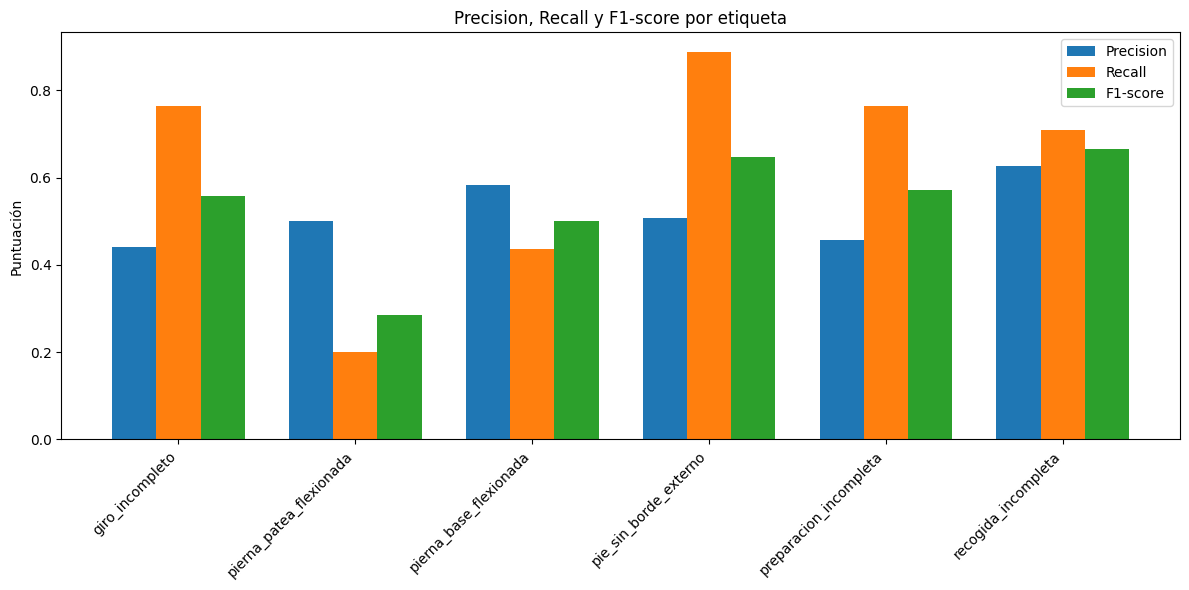

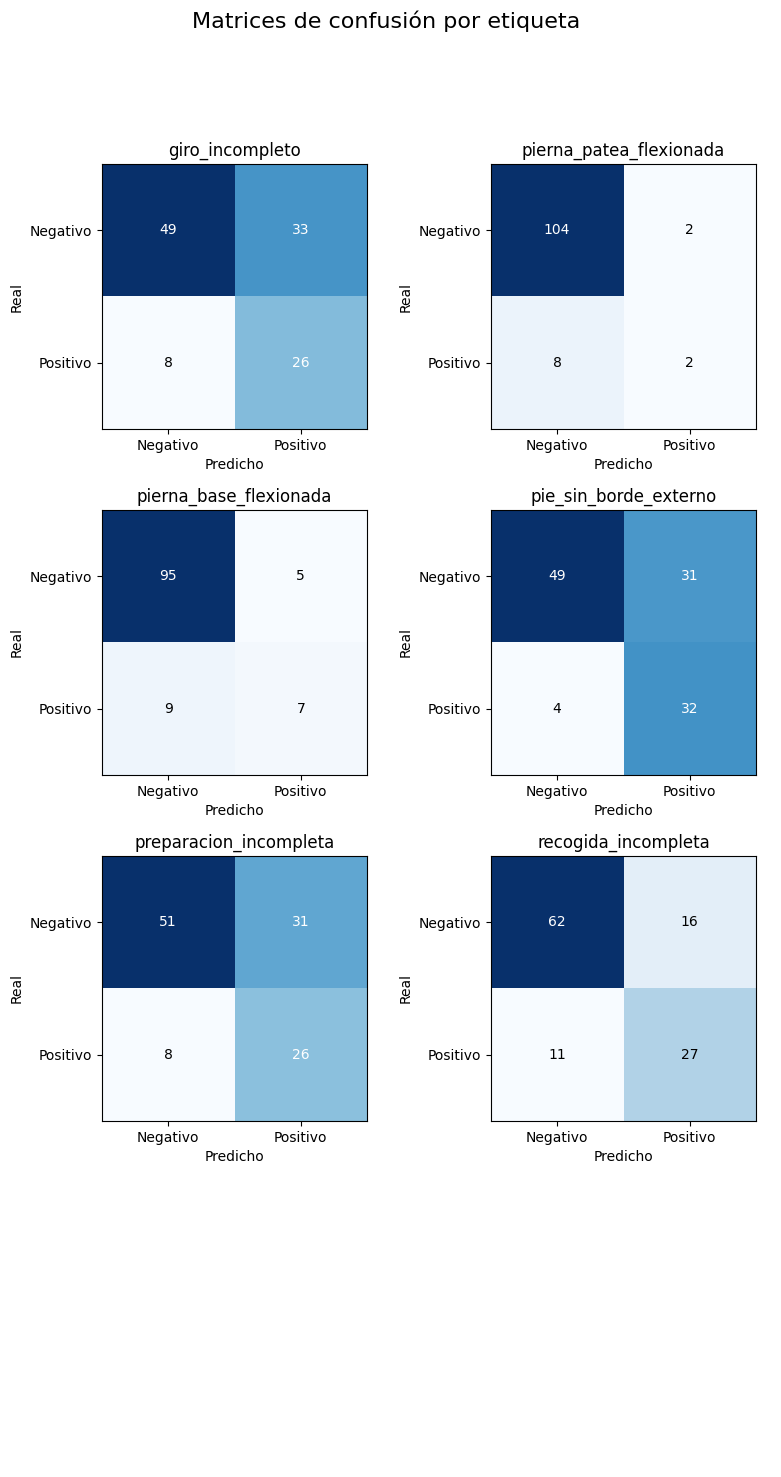

In [49]:
### 17) Mostrar matrices de confusión
# 1) Cálculo de métricas por etiqueta
precisions = precision_score(y_val, y_pred, average=None)
recalls = recall_score(y_val, y_pred, average=None)
f1s = f1_score(y_val, y_pred, average=None)

# 2) Gráfico de barras: precision, recall y f1-score por etiqueta
x = np.arange(len(all_cols))  # posiciones en el eje x para cada etiqueta
width = 0.25  # ancho de cada barra

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, precisions, width, label='Precision')
ax.bar(x, recalls, width, label='Recall')
ax.bar(x + width, f1s, width, label='F1-score')

ax.set_xticks(x)
ax.set_xticklabels(all_cols, rotation=45, ha='right')
ax.set_ylabel('Puntuación')
ax.set_title('Precision, Recall y F1-score por etiqueta')
ax.legend()
plt.tight_layout()
plt.show()
plot_multi_label_confusion(y_val, y_pred, all_cols, normalize=False)


In [50]:
label = "pierna_base_flexionada"
idx = all_cols.index(label)

y_true_label = y_val[:, idx]
y_pred_label = y_pred[:, idx]

false_negatives = np.where((y_true_label == 1) & (y_pred_label == 0))[0]
false_positives = np.where((y_true_label == 0) & (y_pred_label == 1))[0]

print(f"\n🔎 Resultados para la etiqueta: {label}\n")

print(f"❌ Falsos negativos ({len(false_negatives)} casos):")
for i in false_negatives:
    print(f"   - {videos_val[i]}")

print(f"\n⚠️ Falsos positivos ({len(false_positives)} casos):")
for i in false_positives:
    print(f"   - {videos_val[i]}")

print("\n📊 Resumen:")
print(f"   Total falsos negativos: {len(false_negatives)}")
print(f"   Total falsos positivos: {len(false_positives)}")
print(f"   Total errores: {len(false_negatives) + len(false_positives)}\n")





🔎 Resultados para la etiqueta: pierna_base_flexionada

❌ Falsos negativos (9 casos):
   - Adrian_Muñoz14.mp4
   - Z39.mp4
   - Z5.mp4
   - Hanz_Tadeya7.mp4
   - Lourdes6.mp4
   - Ariana_Zevallos6.mp4
   - Z56.mp4
   - Daniela_Lopez1.mp4
   - Z41.mp4

⚠️ Falsos positivos (5 casos):
   - Z60.mp4
   - Adrian_Muñoz10.mp4
   - Z62.mp4
   - Adrian_Muñoz7.mp4
   - Gabriela19.mp4

📊 Resumen:
   Total falsos negativos: 9
   Total falsos positivos: 5
   Total errores: 14



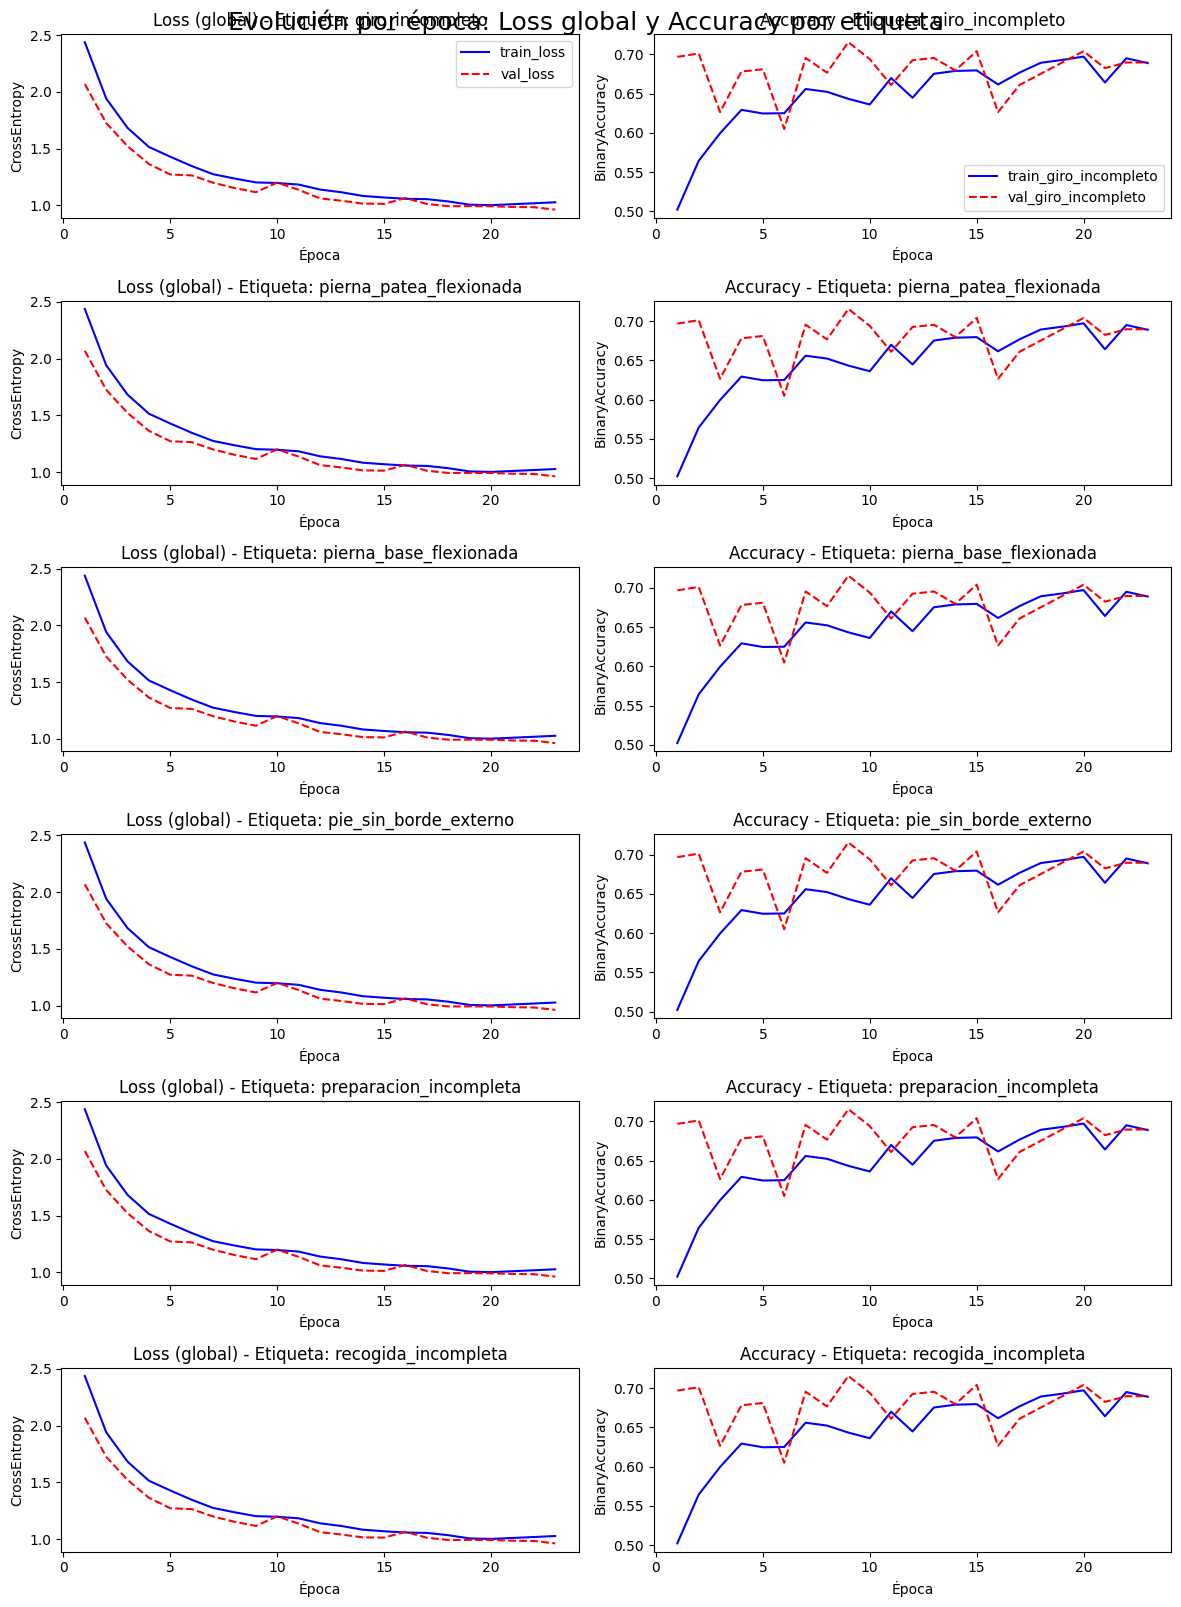

In [51]:
### 18) Mostrar curvas por etiqueta
plot_per_label_curves(history, all_cols)
